
# Phase 3 — Model Development  
## Claim Outcome Classification Model

### Business Objective
The goal of this model is to predict the **insurance claim outcome**
(`Paid`, `Pending`, `Rejected`) in order to:

- Identify high rejection risk early
- Reduce revenue leakage
- Improve billing workflow efficiency
- Support financial planning decisions

### Target Variable
`claim_status`

This is a **multi-class classification problem**.

## Step 1 — Import Required Libraries

In [1]:

# Basic data handling
import pandas as pd
import numpy as np

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Model saving
import joblib
from sklearn.preprocessing import StandardScaler



## Step 2 — Load Modeling Dataset

This dataset was generated in Phase 2 after:
- Data cleaning
- Feature engineering
- SQL-consistent joins

File used: `model_table.csv`


In [2]:

# Load dataset
df = pd.read_csv(r".\data\model_table.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (25000, 33)


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,approval_ratio,payment_delay_flag,visit_frequency,avg_los_per_patient,is_rejected,provider_rejection_rate,age_group,los_category,visit_intensity,dept_high_risk_rate
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,0.0,0,2,3.725000,1,0.148655,Senior,Short,0.030769,0.189950
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,1.0,0,4,32.025000,0,0.156915,Adult,Medium,-0.019417,0.202209
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,1.0,0,4,20.542500,0,0.149678,Adult,Long,0.444444,0.207923
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,1.0,0,7,28.165714,0,0.152480,Senior,Long,-0.112903,0.189950
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,1.0,0,5,22.988000,0,0.149678,Senior,Medium,5.000000,0.198439


## Step 3 — Convert Date Column

We convert `visit_date` to datetime format
to perform a proper time-based train/test split.

In [ ]:
# Convert to datetime so we can sort by date for the time-based train/test split
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")


## Step 4 — Define Target Variable

Target: `claim_status`

In [4]:
# Drop rows where claim_status is unknown — we can't train on unlabelled outcomes
df = df[df["claim_status"].notna()]

# Target variable: three-class label (Paid / Pending / Rejected)
y = df["claim_status"]

print("Claim Status Distribution:")
print(y.value_counts())   # Check for class imbalance before modelling


Claim Status Distribution:
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64



## Step 5 — Feature Selection (Financial Focus)

We select features relevant to billing and claim processing.

In [ ]:
# Ten features aligned to claim_features.json — must match API schema exactly
feature_columns = [
    'age', 'gender', 'department', 'visit_type',
    'length_of_stay_hours', 'visit_frequency',
    'chronic_flag', 'provider_rejection_rate',
    "visit_intensity", 'billed_amount'
]

X = df[feature_columns]

# Fill NaN with 0 — safe default for numeric features; categoricals are encoded next step
X = X.fillna(0)



## Step 6 — Time-Based Train/Test Split

As required in the capstone:

- Earliest 80% → Training
- Latest 20% → Testing

This prevents future information leakage.


In [6]:
# Sort dataset by visit_date
df_sorted = df.sort_values("visit_date")

X_sorted = df_sorted[feature_columns].fillna(0)

# Encode categorical columns to numeric
X_sorted["gender"] = X_sorted["gender"].map({"M": 1, "F": 0}).fillna(0)

# Encode department using factorize (converts categories to numeric codes)
X_sorted["department"] = pd.factorize(X_sorted["department"])[0]

# Encode visit_type using factorize
X_sorted["visit_type"] = pd.factorize(X_sorted["visit_type"])[0]

y_sorted = df_sorted["claim_status"]

# Create split index
split_index = int(len(df_sorted) * 0.8)

# Training data
X_train = X_sorted.iloc[:split_index]
y_train = y_sorted.iloc[:split_index]

# Testing data
X_test = X_sorted.iloc[split_index:]
y_test = y_sorted.iloc[split_index:]

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (20000, 10)
Testing Size: (5000, 10)


### Business Context — Claim Model Preprocessing
Unlike the risk model (which uses a full sklearn Pipeline with OrdinalEncoder), the claim model is a **raw RandomForestClassifier**. This means categorical columns must be manually integer-encoded before `.fit()` and `.predict()`. The `pd.factorize()` codes are preserved in `claim_features.json` and replicated in the production API (`utils.py`) to guarantee identical encoding at inference time, preventing train/serve skew.

## Step 7 — Baseline Model: Logistic Regression (With Class Weight)

Claim outcomes are often imbalanced.
We use `class_weight='balanced'` to handle imbalance.

In [7]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform train and test
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Initialize Logistic Regression
baseline_model = LogisticRegression(
    max_iter=3000,        # Increased iterations
    class_weight="balanced",
    solver="lbfgs"
)

# Train model
baseline_model.fit(X_train_scaled, y_train)

# Predict
y_pred_baseline = baseline_model.predict(X_test_scaled)


### Evaluate Baseline Model

In [8]:
# Confusion matrix shows per-class prediction counts (rows = actual, cols = predicted)
print("Confusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_baseline))

# Focus on Recall and F1 for the 'Rejected' class — low recall = missed revenue risk
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))


Confusion Matrix (Baseline):
[[1190  683 1124]
 [ 488  277  510]
 [ 212  218  298]]

Classification Report (Baseline):
              precision    recall  f1-score   support

        Paid       0.63      0.40      0.49      2997
     Pending       0.24      0.22      0.23      1275
    Rejected       0.15      0.41      0.22       728

    accuracy                           0.35      5000
   macro avg       0.34      0.34      0.31      5000
weighted avg       0.46      0.35      0.38      5000



### Business Context — Baseline Model Limitations
Logistic Regression with `class_weight='balanced'` establishes a performance floor. It is useful for checking whether the feature set carries any signal at all, but it assumes linear separability between claim outcomes — an assumption that rarely holds in healthcare billing where interactions (e.g., high-LOS ICU visits from frequent attendees) are what drive rejections. Low recall on **Rejected** class from the baseline motivates the switch to Random Forest.

## Step 8 — Advanced Model: Random Forest

Random Forest handles nonlinear relationships and imbalance better.

In [ ]:
# Tuned Random Forest — no pipeline wrapper needed since encoding is done manually above
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,       # 200 trees reduces prediction variance vs a single tree
    max_depth=20,           # Deep enough to capture billing interaction patterns
    min_samples_split=4,    # Require at least 4 samples before further splitting a node
    min_samples_leaf=1,     # Allow single-sample leaves for fine-grained boundaries
    class_weight="balanced",# Compensate for Paid >> Pending >> Rejected class counts
    random_state=42,        # Reproducible results across runs
    n_jobs=-1               # Parallelise tree building across all CPU cores
)

# Train directly on encoded integer-feature matrix (no pipeline preprocessing step)
rf_model_tuned.fit(X_train, y_train)

# Predict on the chronologically most-recent 20% of claims
y_pred_rf_tuned = rf_model_tuned.predict(X_test)


### Evaluate Random Forest Model

In [15]:
# Compare with Logistic Regression results above — RF should improve Rejected recall
print("Confusion Matrix (Tuned RF):")
print(confusion_matrix(y_test, y_pred_rf_tuned))

# Higher macro F1 confirms better balance across all three claim outcome classes
print("\nClassification Report (Tuned RF):")
print(classification_report(y_test, y_pred_rf_tuned))


Confusion Matrix (Tuned RF):
[[2552   92  353]
 [1059   40  176]
 [ 520   30  178]]

Classification Report (Tuned RF):
              precision    recall  f1-score   support

        Paid       0.62      0.85      0.72      2997
     Pending       0.25      0.03      0.06      1275
    Rejected       0.25      0.24      0.25       728

    accuracy                           0.55      5000
   macro avg       0.37      0.38      0.34      5000
weighted avg       0.47      0.55      0.48      5000



### Business Context — Random Forest for Claim Prediction
Random Forest is well-suited for claim outcome prediction because:
- **`provider_rejection_rate`** and **`visit_intensity`** are high-cardinality continuous features with non-linear thresholds
- **`class_weight='balanced'`** compensates for the natural imbalance where Paid claims outnumber Rejected ones
- Tree splitting is unaffected by different scales of `billed_amount` vs `chronic_flag` — no normalisation required
- The ensemble of 200 trees reduces variance introduced by edge-case billing patterns

Focus on the **Rejected** class recall (minimise revenue leakage from undetected rejections) when interpreting the classification report.

## Step 9 — Save Best Model

We save the Random Forest model for deployment.

In [16]:
# Save only the RandomForestClassifier (no pipeline wrapper).
# Categorical encoding is handled separately at inference time by utils.py.
joblib.dump(rf_model_tuned, "./data/claim_model.pkl", compress=3)
print("Claim model saved successfully as claim_model.pkl")


Claim model saved successfully as claim_model.pkl


### Business Context — Model Artifact (Claim Model)
`claim_model.pkl` stores only the **raw `RandomForestClassifier`** — no preprocessing pipeline. This is intentional: the training pipeline used `StandardScaler` for Logistic Regression comparisons, but the final Random Forest model does not benefit from scaling. The production API in `utils.py` replicates the encoding logic to ensure consistent feature representation at inference time.

## Analyze Class Imbalance

Risk Score Distribution
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64

Claim Status Distribution
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64


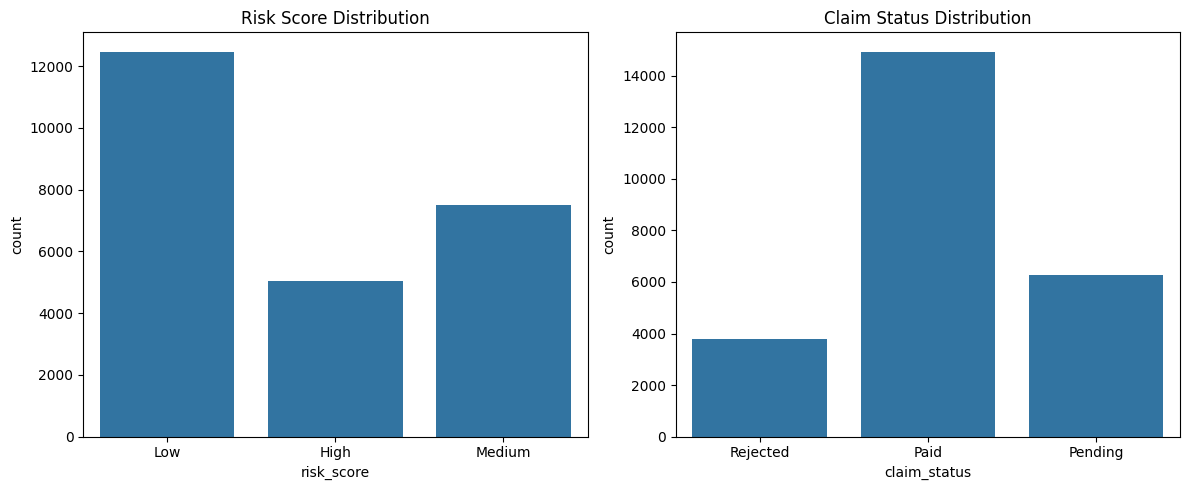

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Print raw counts first for exact numbers before plotting
print("Risk Score Distribution")
print(df["risk_score"].value_counts())

print("\nClaim Status Distribution")
print(df["claim_status"].value_counts())

# Side-by-side bar charts — visual confirmation of class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=df["risk_score"], ax=axes[0])
axes[0].set_title("Risk Score Distribution")    # Low / Medium / High

sns.countplot(x=df["claim_status"], ax=axes[1])
axes[1].set_title("Claim Status Distribution")  # Paid / Pending / Rejected

plt.tight_layout()
plt.show()


### Business Context — Class Imbalance in Claim Outcomes
Insurance claim datasets are inherently imbalanced: most claims are **Paid**, a minority are **Pending**, and a smaller subset are **Rejected**. This distribution reflects real-world billing, where providers favour claims likely to be approved. The imbalance motivates the use of `class_weight='balanced'` and, in Phase 4, SMOTE resampling. Without addressing imbalance, a naïve model could achieve high accuracy by predicting "Paid" for every visit — missing all revenue-risk signals.

In [ ]:
## Generate features.json from trained model

In [18]:
# -----------------------------------
# Create Claim Feature Schema JSON
# -----------------------------------

import json

claim_schema = {
    "model_name": "claim_prediction_model",
    "features": {
        "age": {"dtype": "numeric"},
        "gender": {"dtype": "category", "values": ["F", "M"]},
        "department": {"dtype": "category", "values": ["Cardiology", "ER", "General", "ICU", "Neurology", "Orthopedics"]},
        "visit_type": {"dtype": "category", "values": ["ER", "ICU", "OPD"]},
        "length_of_stay_hours": {"dtype": "numeric"},
        "visit_frequency": {"dtype": "numeric"},
        "chronic_flag": {"dtype": "numeric"},
        "provider_rejection_rate": {"dtype": "numeric"},
        "visit_intensity": {"dtype": "numeric"},
        "billed_amount": {"dtype": "numeric"}
    }
}

with open("./data/claim_features.json", "w") as f:
    json.dump(claim_schema, f, indent=4)

print("Claim feature schema saved successfully.")


Claim feature schema saved successfully.


### Business Context — Feature Schema Contract
`claim_features.json` acts as a **contract** between the training notebook and the production API. It specifies:
- Exact feature names (in training order)
- Data types (`numeric` vs `category`) so the API knows which columns to encode
- Allowed values for categorical fields (used for input validation in Pydantic schemas)

Any future model retraining must update this JSON to keep the API in sync. The schema is also consumed by `utils.py` to dynamically build the feature DataFrame for inference.